# Cifar-10 and Fully Connected Neural Network 

This notebook is part of a Cifar-10 assignment for the Neural Network Project course at Metropolia University of Applied Sciences. The notebook demonstrates how to build and train a fully connected neural network (FCN) for image classification using the CIFAR-10 dataset. The CIFAR-10 dataset consists of 60 000 32x32 color images in 10 classes, with 6000 images per class. The aim is to achieve a test accuracy of at least 50% using a fully connected neural network. The cifar10_cnn.ipynb notebook contains a convolutional neural network (CNN) implementation for the same dataset so that these two can be compared. 


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
from tensorflow.keras import datasets, layers, utils, Model, Input
# from tensorflow.keras.callbacks import EarlyStopping

# Load the CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}, Test labels shape: {y_test.shape}")

# Preprocess: normalization and reshaping
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Flatten labels and one-hot encode
y_train = utils.to_categorical(y_train.reshape(-1), 10)
y_test = utils.to_categorical(y_test.reshape(-1), 10)

c:\Users\nealu\anaconda3\envs\keras\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training data shape: (50000, 32, 32, 3), Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3), Test labels shape: (10000, 1)


The dataset is now ready for training. A function is defined to create a fully connected netword and then the model is trained with different variations and compared. Early stopping was implemented to prevent overfitting and to save time. However, as the models are very fluctuating, the early stopping stopped some models too early and thus it was commented out. 

In [2]:
def create_fcn_model(hidden_units=256, input_shape=(32,32,3), num_classes=10):
    inputs = Input(shape=input_shape)
    x = layers.Flatten()(inputs)
    x = layers.Dense(hidden_units, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [3]:
# Train models and collect metrics
hidden_units_list = [128, 256, 512]  # Number of hidden units
batch_sizes = [64, 128]              # Batch sizes
epochs = 30                          # Max epochs
#early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

histories = {}
test_accuracies = {}
train_times = {}
num_params = {}

for units in hidden_units_list:
    for batch in batch_sizes:
        name = f"{units}_units_batch{batch}"
        print(f"\nTraining {name}...")
        model = create_fcn_model(hidden_units=units)
        num_params[name] = model.count_params()
        
        start_time = time.time()
        history = model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch,
            validation_split=0.2,
            # callbacks=[early_stop],
            verbose=1
        )
        train_times[name] = time.time() - start_time
        histories[name] = history
        
        # Evaluate test set
        loss, acc = model.evaluate(X_test, y_test, verbose=0)
        test_accuracies[name] = acc
        print(f"{name} - Test Accuracy: {acc:.4f}, Parameters: {num_params[name]}, Training Time: {train_times[name]:.2f}s")



Training 128_units_batch64...
Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3076 - loss: 1.9331 - val_accuracy: 0.3590 - val_loss: 1.8116
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3739 - loss: 1.7607 - val_accuracy: 0.3710 - val_loss: 1.7686
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3981 - loss: 1.6994 - val_accuracy: 0.3914 - val_loss: 1.7155
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4107 - loss: 1.6674 - val_accuracy: 0.4054 - val_loss: 1.6816
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4174 - loss: 1.6448 - val_accuracy: 0.4082 - val_loss: 1.6916
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4244 - loss: 1.6217 - val_accuracy: 0.4219 - val_loss: 1.6468
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4286 - loss: 1.6086 - val_accuracy: 0.4127 - val_loss: 1.6636
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4347 - 

Next the learning curves are plotted to visualize the training and validation performance over epochs.

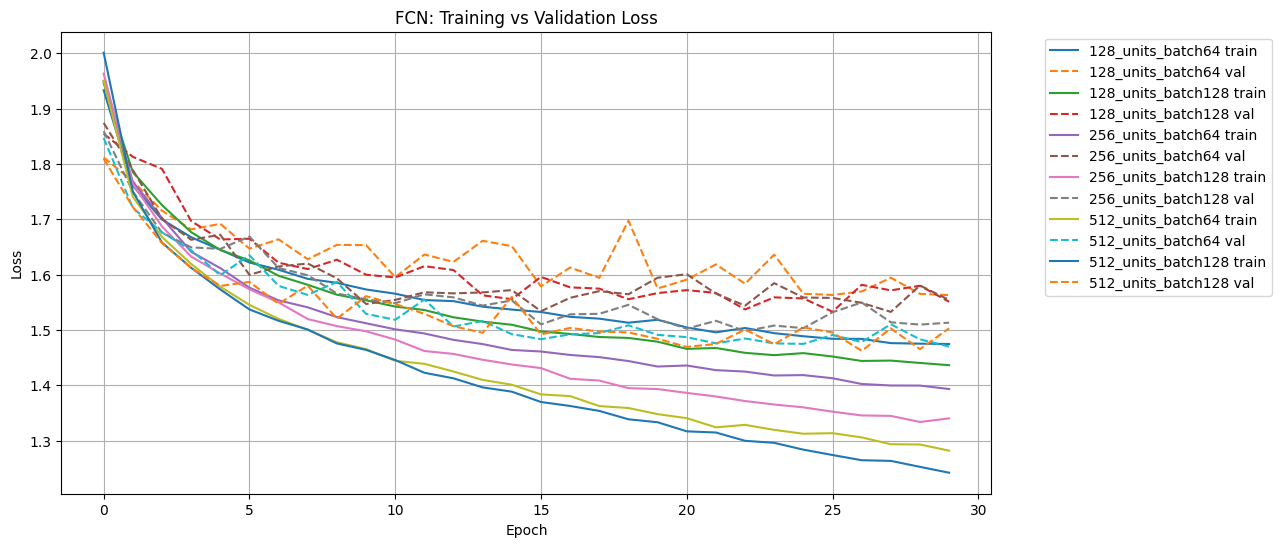

In [4]:
# Plot learning curves
plt.figure(figsize=(12,6))
for name, history in histories.items():
    plt.plot(history.history['loss'], label=f'{name} train')
    plt.plot(history.history['val_loss'], '--', label=f'{name} val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('FCN: Training vs Validation Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

In [5]:
# Compare metrics in table
comparison = pd.DataFrame({
    "Test Accuracy": test_accuracies,
    "Parameters": num_params,
    "Training Time (s)": train_times
}).sort_values("Test Accuracy", ascending=False)

print(comparison)

                    Test Accuracy  Parameters  Training Time (s)
512_units_batch64          0.4891     1578506         272.049535
512_units_batch128         0.4792     1578506         148.736625
256_units_batch128         0.4745      789258          72.850028
256_units_batch64          0.4619      789258         118.000578
128_units_batch128         0.4573      394634          38.781735
128_units_batch64          0.4572      394634          63.985739


Based on this analysis, the amount of epochs is also tested for 512 unit models for both batch sizes to see if the accuracy can be improved by training longer. The chosen models are the ones with the best validation accuracy for each batch size and therefore the most promising ones to improve. It could be considered to run for all models, but as the training is quite long, it is only tested for the best ones to save time. But choosing the best for both batches does not discriminate between the batch sizes as the accuracies between the worst for 128 batch and the best for 64 batch are almost the same. Choosing only the best 2 at this stage would have been more biased towards the 128 batch size.

In [6]:
# Chosen models for epoch exploration
chosen_configs = [
    {'name': '512_units_batch128', 'hidden': 512, 'batch': 128},
    {'name': '512_units_batch64',  'hidden': 512, 'batch': 64}
]

# Epochs to experiment with
epoch_list = [40, 50, 60]

# Dictionaries to store results
epoch_histories = {}
epoch_test_accuracies = {}
epoch_train_times = {}
epoch_num_params = {}

for config in chosen_configs:
    for ep in epoch_list:
        name = f"{config['name']}_{ep}epochs"
        print(f"\nTraining {name}...")

        # Create new model for each run
        model = create_fcn_model(hidden_units=config['hidden'])
        epoch_num_params[name] = model.count_params()

        start_time = time.time()
        history = model.fit(
            X_train, y_train,
            epochs=ep,
            batch_size=config['batch'],
            validation_split=0.2,
            verbose=1
        )
        epoch_train_times[name] = time.time() - start_time
        epoch_histories[name] = history

        # Evaluate test set
        loss, acc = model.evaluate(X_test, y_test, verbose=0)
        epoch_test_accuracies[name] = acc

        print(f"{name} - Test Accuracy: {acc:.4f}, Parameters: {epoch_num_params[name]}, Training Time: {epoch_train_times[name]:.2f}s")

# Update history
histories.update(epoch_histories)
test_accuracies.update(epoch_test_accuracies)
train_times.update(epoch_train_times)



Training 512_units_batch128_40epochs...
Epoch 1/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.3096 - loss: 1.9917 - val_accuracy: 0.3607 - val_loss: 1.8226
Epoch 2/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.3746 - loss: 1.7670 - val_accuracy: 0.3856 - val_loss: 1.7421
Epoch 3/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4062 - loss: 1.6766 - val_accuracy: 0.4105 - val_loss: 1.6673
Epoch 4/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4268 - loss: 1.6202 - val_accuracy: 0.3830 - val_loss: 1.7196
Epoch 5/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4356 - loss: 1.5919 - val_accuracy: 0.4322 - val_loss: 1.6119
Epoch 6/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4505 - loss: 1.5559 - val_accuracy: 0.4448 - val_loss: 1.5744
Epoch 7/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4588 - loss: 1.5277 - val_accuracy: 0.4489 - val_loss: 1.5653
Epoch 8/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - a

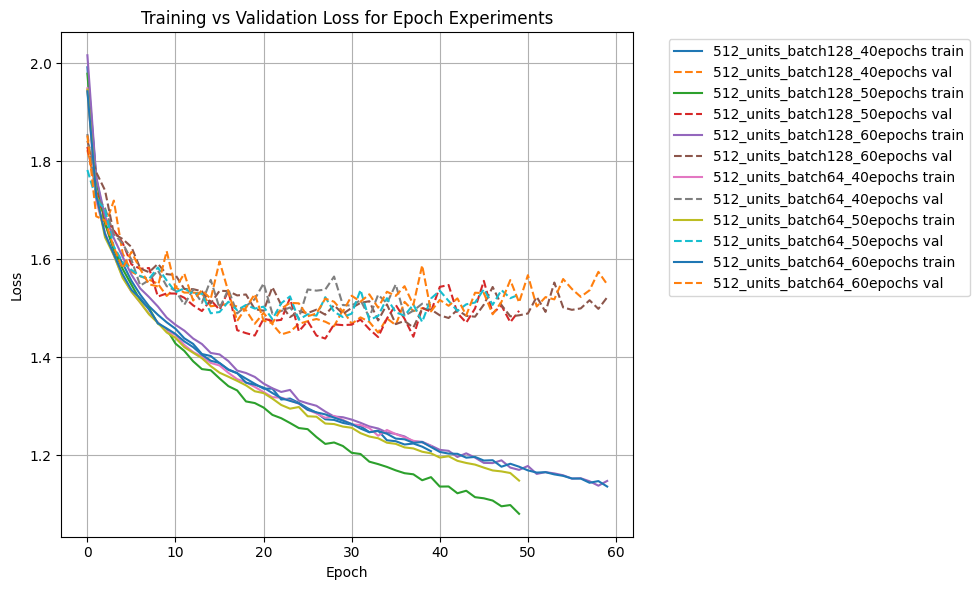

In [7]:
plt.figure(figsize=(10,6))

for name, history in epoch_histories.items():
    plt.plot(history.history['loss'], label=f'{name} train')
    plt.plot(history.history['val_loss'], linestyle='--', label=f'{name} val')

plt.title('Training vs Validation Loss for Epoch Experiments')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.tight_layout()
plt.show()

In [8]:
epoch_results = pd.DataFrame({
    'Test Accuracy': epoch_test_accuracies,
    'Parameters': epoch_num_params,
    'Training Time (s)': epoch_train_times
}).sort_values(by='Test Accuracy', ascending=False)

print(epoch_results)

                             Test Accuracy  Parameters  Training Time (s)
512_units_batch128_50epochs         0.5012     1578506         253.853841
512_units_batch128_40epochs         0.4931     1578506         197.253264
512_units_batch64_50epochs          0.4919     1578506         662.673269
512_units_batch128_60epochs         0.4885     1578506         304.217728
512_units_batch64_40epochs          0.4869     1578506         362.552736
512_units_batch64_60epochs          0.4731     1578506         676.989266


When compared with the results from the 30 epoch training, the epoch amount does not seem to have any effect on the accuracy. The training time is of course much longer, but the accuracy is still at 47-49%.  

As the accuracies are still basically the same and quite low, the same models (512 unit models with both batch sizes) are chosen to be improved with dropout, batch normalization and data augmentation. The same models are chosen to be improved to keep the comparison between the batch sizes fair.

In [9]:
# FCN model creator with dropout and augmentation layers with batch normalization
def create_fcn_dropout_aug(hidden_units=256, dropout_rate=0.2, input_shape=(32,32,3), num_classes=10):
    inputs = Input(shape=input_shape)
    
    # Data augmentation layers applied only during training
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)
    
    # FCN layers
    x = layers.Flatten()(x)
    x = layers.Dense(hidden_units, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [10]:
# Improve models with dropout, augmentation and batch normalization based on previous results
improved_configs = [
    {'name': '512_units_batch128', 'hidden': 512, 'batch': 128},
    {'name': '512_units_batch64',  'hidden': 512, 'batch': 64}
]

improved_histories = {}
improved_test_accuracies = {}
improved_train_times = {}
improved_num_params = {}
# early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

for config in improved_configs:
    print(f"\nTraining improved model: {config['name']}...")
    model = create_fcn_dropout_aug(hidden_units=config['hidden'], dropout_rate=0.2)
    improved_num_params[f"{config['name']}_improved"] = model.count_params()
    
    start_time = time.time()
    
    # Train using normal fit (no generator)
    history = model.fit(
        X_train, y_train,
        batch_size=config['batch'],
        epochs=30,
        validation_split=0.2,
        # callbacks=[early_stop],
        verbose=0
    )
    
    improved_train_times[f"{config['name']}_improved"] = time.time() - start_time
    improved_histories[f"{config['name']}_improved"] = history
    
    # Evaluate test set
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    improved_test_accuracies[f"{config['name']}_improved"] = acc
    key = f"{config['name']}_improved"
    print(f"{config['name']} - Test Accuracy: {acc:.4f}, "
      f"Parameters: {improved_num_params[key]}, "
      f"Training Time: {improved_train_times[key]:.2f}s")
                                             
# Combine histories for later plotting
histories.update(improved_histories)
test_accuracies.update(improved_test_accuracies)
train_times.update(improved_train_times)



Training improved model: 512_units_batch128...
512_units_batch128 - Test Accuracy: 0.4078, Parameters: 1580554, Training Time: 214.69s

Training improved model: 512_units_batch64...
512_units_batch64 - Test Accuracy: 0.4587, Parameters: 1580554, Training Time: 323.60s


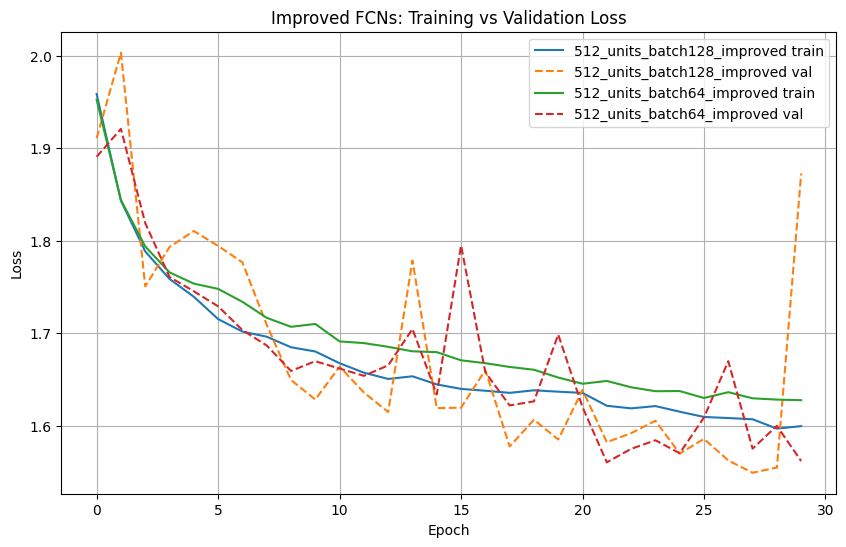

In [11]:
# Plot learning curves
plt.figure(figsize=(10,6))
for name, history in improved_histories.items():
    plt.plot(history.history['loss'], label=f'{name} train')
    plt.plot(history.history['val_loss'], '--', label=f'{name} val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Improved FCNs: Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [12]:
# Compare metrics
improved_comparison = pd.DataFrame({
    "Test Accuracy": improved_test_accuracies,
    "Parameters": improved_num_params,
    "Training Time (s)": improved_train_times
}).sort_values("Test Accuracy", ascending=False)

print(improved_comparison)

                             Test Accuracy  Parameters  Training Time (s)
512_units_batch64_improved          0.4587     1580554         323.595299
512_units_batch128_improved         0.4078     1580554         214.686793


This shows that a fully connected network is not the best choice for image classification tasks, as it does not capture spatial hierarchies in the data. No matter how the model is tweaked, the accuracy remains low. Finally, the best model is used to evaluate how the model predicts images.

In [13]:
#Print all test accuracies for reference
print("All Test Accuracies:")
for name, acc in test_accuracies.items():
    print(f"{name}: {acc:.4f}") 
    

All Test Accuracies:
128_units_batch64: 0.4572
128_units_batch128: 0.4573
256_units_batch64: 0.4619
256_units_batch128: 0.4745
512_units_batch64: 0.4891
512_units_batch128: 0.4792
512_units_batch128_40epochs: 0.4931
512_units_batch128_50epochs: 0.5012
512_units_batch128_60epochs: 0.4885
512_units_batch64_40epochs: 0.4869
512_units_batch64_50epochs: 0.4919
512_units_batch64_60epochs: 0.4731
512_units_batch128_improved: 0.4078
512_units_batch64_improved: 0.4587


It would seem that no matter what, the model´s accuracy is quite low. Finally, let´s see how the best model performs with more layers.

In [14]:
depth_configs = {
    "2D_model": [512, 256],
    "3D_model": [512, 256, 128],
    "4D_model": [512, 384, 256, 128]
}

depth_histories = {}
depth_test_accuracies = {}
depth_train_times = {}
depth_num_params = {}

for name, neurons in depth_configs.items():
    print(f"\nTraining {name} with layers {neurons}...")

    # Build model
    inputs = layers.Input(shape=(32,32,3,))
    x = layers.Flatten()(inputs)
    for n in neurons:
        x = layers.Dense(n, activation='relu')(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=outputs)

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Train
    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        epochs=30,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )
    train_time = time.time() - start_time

    # Evaluate
    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    # Store metrics
    depth_test_accuracies[name] = acc
    depth_train_times[name] = train_time
    depth_num_params[name] = model.count_params()
    depth_histories[name] = history
    print(f"{name} - Test Accuracy: {acc:.4f}, Parameters: {model.count_params()}, Training Time: {train_time:.2f}s")

# Combine histories for later plotting
histories.update(depth_histories)
test_accuracies.update(depth_test_accuracies)
train_times.update(depth_train_times)
num_params.update(depth_num_params)


Training 2D_model with layers [512, 256]...
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.3144 - loss: 1.9135 - val_accuracy: 0.3642 - val_loss: 1.7776
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.3926 - loss: 1.6983 - val_accuracy: 0.4064 - val_loss: 1.6889
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4207 - loss: 1.6256 - val_accuracy: 0.4114 - val_loss: 1.6485
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4415 - loss: 1.5648 - val_accuracy: 0.4383 - val_loss: 1.5877
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4588 - loss: 1.5150 - val_accuracy: 0.4454 - val_loss: 1.5615
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4707 - loss: 1.4833 - val_accuracy: 0.4433 - val_loss: 1.5848
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4824 - loss: 1.4513 - val_accuracy: 0.4684 - val_loss: 1.4915
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step

It would seem that the best way to improve the model is to add more capacity, as the accuracy is improved by adding an extra hidden layer. However, the accuracy is still quite low and the training time is much longer.

In [15]:
# Compare metrics
depth_comparison = pd.DataFrame({
    "Test Accuracy": depth_test_accuracies,
    "Parameters": depth_num_params,
    "Training Time (s)": depth_train_times
}).sort_values("Test Accuracy", ascending=False)

print(depth_comparison)

          Test Accuracy  Parameters  Training Time (s)
2D_model         0.5110     1707274         169.251945
3D_model         0.5078     1738890         170.563179
4D_model         0.4973     1903114         185.726378


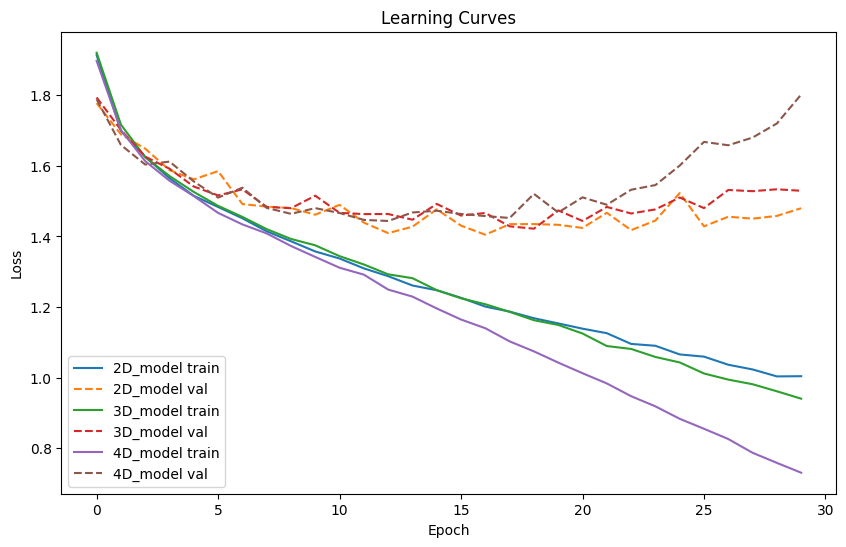

In [16]:
# Plot learning curves
plt.figure(figsize=(10,6))
for name, history in depth_histories.items():
    plt.plot(history.history['loss'], label=f'{name} train')
    plt.plot(history.history['val_loss'], '--', label=f'{name} val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curves')
plt.legend()
plt.show()

In [17]:
print("All Test Accuracies:")
for model_name, acc in sorted(test_accuracies.items(), key=lambda item: item[1], reverse=True):
    print(f"{model_name}: {acc:.4f}")

All Test Accuracies:
2D_model: 0.5110
3D_model: 0.5078
512_units_batch128_50epochs: 0.5012
4D_model: 0.4973
512_units_batch128_40epochs: 0.4931
512_units_batch64_50epochs: 0.4919
512_units_batch64: 0.4891
512_units_batch128_60epochs: 0.4885
512_units_batch64_40epochs: 0.4869
512_units_batch128: 0.4792
256_units_batch128: 0.4745
512_units_batch64_60epochs: 0.4731
256_units_batch64: 0.4619
512_units_batch64_improved: 0.4587
128_units_batch128: 0.4573
128_units_batch64: 0.4572
512_units_batch128_improved: 0.4078


Looking at all the learning curves and the list of all accuracies, it seems that the best model is the one with 2 hidden layers. All other models are showing signs of overfitting where the val-loss curve is fluctuating and not remarkably improving while the training loss is improving (decreasing). It is then safe to pick the best model from the test accuracies list. The accuracy for the model is 50,31%. Next we will test the model with the test set to see how it performs with unseen data.

Best model: 2D_model with Test Accuracy: 0.5110
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
(10, 32, 32, 3)
(32, 32, 3)
0.007843138 1.0


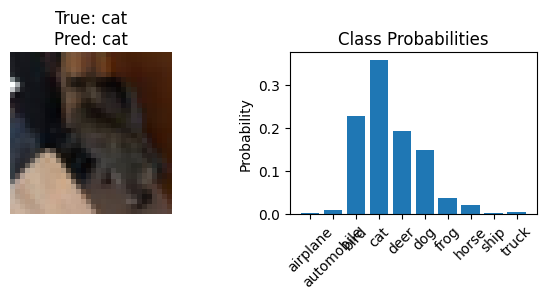

(10, 32, 32, 3)
(32, 32, 3)
0.07450981 0.972549


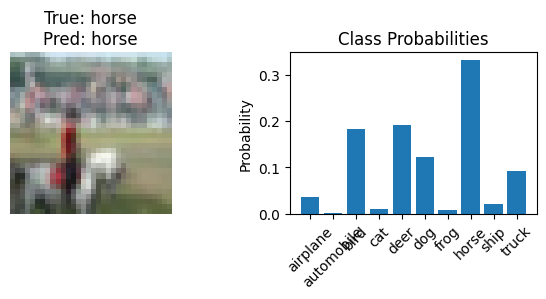

(10, 32, 32, 3)
(32, 32, 3)
0.011764706 0.99215686


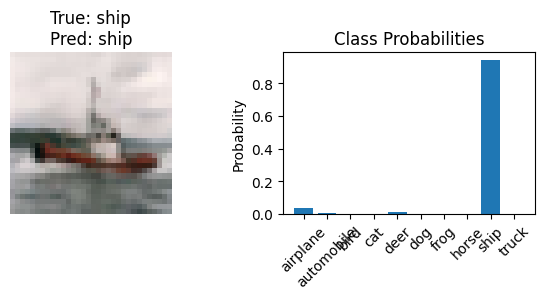

(10, 32, 32, 3)
(32, 32, 3)
0.050980393 0.8666667


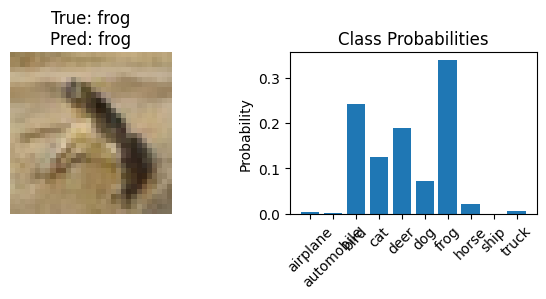

(10, 32, 32, 3)
(32, 32, 3)
0.003921569 1.0


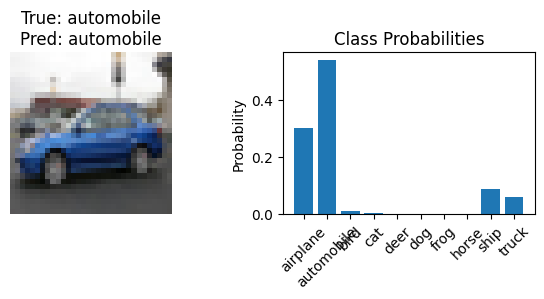

(10, 32, 32, 3)
(32, 32, 3)
0.0 1.0


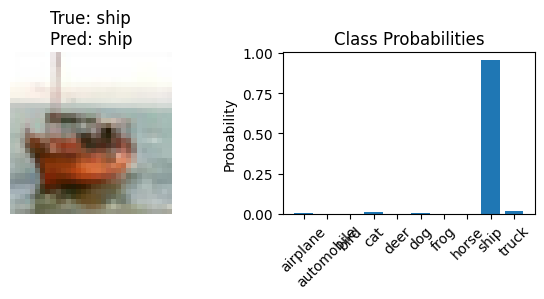

(10, 32, 32, 3)
(32, 32, 3)
0.015686275 0.99607843


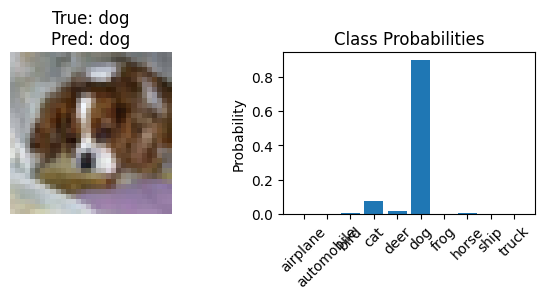

(10, 32, 32, 3)
(32, 32, 3)
0.003921569 1.0


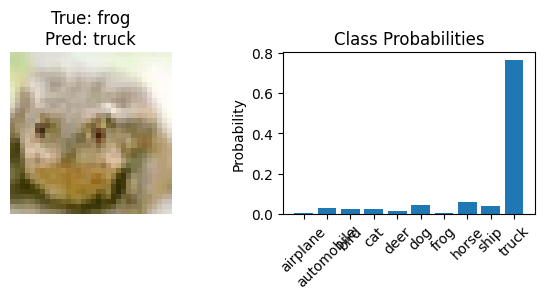

(10, 32, 32, 3)
(32, 32, 3)
0.050980393 0.6666667


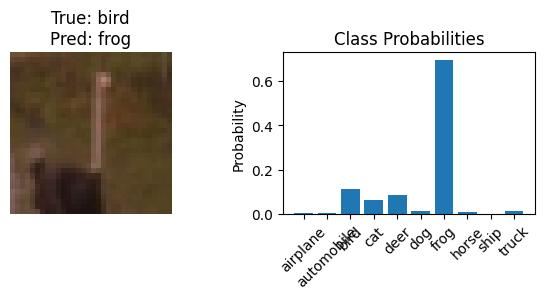

(10, 32, 32, 3)
(32, 32, 3)
0.023529412 0.89411765


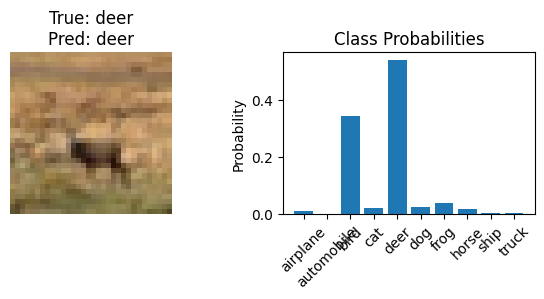

In [18]:
# Choose the best model (highest test accuracy)
best_model_name = max(test_accuracies, key=test_accuracies.get)
best_model = histories[best_model_name].model
print(f"Best model: {best_model_name} with Test Accuracy: {test_accuracies[best_model_name]:.4f}")

# Pick a few random test images
num_examples = 10
indices = np.random.choice(len(X_test), num_examples, replace=False)
X_sample = X_test[indices]
y_true = y_test[indices]

# Get predictions
y_pred_prob = best_model.predict(X_sample)
y_pred_class = np.argmax(y_pred_prob, axis=1)
y_true_class = np.argmax(y_true, axis=1)


# CIFAR-10 class names
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# Visualize images with predictions
for i in range(num_examples):
    plt.figure(figsize=(6,3))
    print(X_sample.shape)
    print(X_sample[i].shape)
    print(np.min(X_sample[i]), np.max(X_sample[i]))
    # Show image
    plt.subplot(1,2,1)
    plt.imshow(X_sample[i])
    plt.axis('off')
    plt.title(f"True: {class_names[y_true_class[i]]}\nPred: {class_names[y_pred_class[i]]}")
    
    # Show probability distribution
    plt.subplot(1,2,2)
    plt.bar(range(10), y_pred_prob[i])
    plt.xticks(range(10), class_names, rotation=45)
    plt.ylabel("Probability")
    plt.title("Class Probabilities")
    
    plt.tight_layout()
    plt.show()

Final test accuracy is 50,10%. This is quite low, but it is still above the 50% threshold. The model is not ideal for image classification tasks, but it is still able to predict some images correctly.

As seen on the images, the model is able to predict easy images correctly. That is, images where the object is clearly visible from the background and that might have predictable backgrounds. Such are the airplane and the ship which both often have blue backgrounds. The failed predictions are often images that are quite garbled and where the object is not distinguishable from the background (look at the deer prediction from the frog image). There is also a bird image that is predicted as a cat and the next highest probability is a dog, which might also indicate that the model might be making predictions based on size and color as the bird in question is quite large and dark.

Overall it would seem that the FCN is not ideal for image classification tasks as no amount of tweaking seems to improve the accuracy and if accuracy is improved, the training time is much longer and overfitting is more likely. Possible improvements could be to alter colors and contrast of the images to make the objects more distinguishable from the background, but still the model might not be able to capture the spatial hierarchies in the data. The convolutional neural network should be a better choice for a task like this. 